In [1]:
# =================================================================
# cartea.ipynb — Phase 3 critique (Cartea, Jin & Shi 2025)
# Claim: complexity's benefit erodes once predictors carry measurement noise.
# Counter-spec: inject Gaussian noise into the standardized predictors,
# re-run the complexity sweep, watch Sharpe degrade as noise rises.
# =================================================================
from google.colab import drive; drive.mount('/content/drive')
import pandas as pd, numpy as np, matplotlib.pyplot as plt

KMZ    = "/content/drive/MyDrive/Summer Research/kmz"
DEBATE = "/content/drive/MyDrive/Summer Research/debate"
MASTER_SEED = 42

# --- engine copied from kmz_pipeline.ipynb — keep in sync ---
def make_rff(G, n_pairs, gamma=2.0, seed=0):
    rng = np.random.default_rng(seed)
    W = rng.standard_normal((n_pairs, G.shape[1])).T   # draw j is the same no matter what n_pairs is
    proj = gamma * (G @ W)
    S = np.empty((G.shape[0], 2 * n_pairs))
    S[:, 0::2] = np.sin(proj)                          # sin/cos interleaved, so the first P columns are P/2 full pairs
    S[:, 1::2] = np.cos(proj)
    return S

# --- sanity check: first P columns must be P/2 sin/cos pairs, independent of n_pairs ---
_G = np.random.default_rng(1).standard_normal((5, 15))
assert np.allclose(make_rff(_G, n_pairs=4, seed=0), make_rff(_G, n_pairs=100, seed=0)[:, :8]), "make_rff is the old version"

def ridge_forecast_dual(S_tr, R_tr, S_t, z):
    T = S_tr.shape[0]
    K = (S_tr @ S_tr.T) / T
    a = np.linalg.solve(K + z*np.eye(T), R_tr/T)
    return float(S_t @ (S_tr.T @ a))

def run_oos_nested(S_full, R, P, T, z):
    assert P % 2 == 0, "P must be even so no sin/cos pair is split"
    S_all = S_full[:, :P]; N = len(R); fc, sr = [], []
    for t in range(T, N):
        S_tr, R_tr = S_all[t-T:t], R[t-T:t]
        sd = S_tr.std(axis=0); sd[sd==0]=1.0
        f = ridge_forecast_dual(S_tr/sd, R_tr, S_all[t]/sd, z)
        fc.append(f); sr.append(f*R[t])
    return np.array(fc), np.array(sr)

# --- data prep copied from kmz_pipeline.ipynb — keep in sync ---
predictors = ["dp","dy","ep","de","svar","bm","ntis","tbl","lty","ltr",
              "tms","dfy","dfr","infl","mktret_lag"]
panel = pd.read_parquet(f"{KMZ}/predictors.parquet").sort_values("date").reset_index(drop=True)
panel["target"] = panel["excess_ret"].shift(-1)

def exp_std(s, mp=36):
    return s / s.expanding(min_periods=mp).std().shift(1)

std = panel.copy()
for c in predictors: std[c] = exp_std(panel[c])
std = std.dropna(subset=predictors+["target"]).reset_index(drop=True)

G = std[predictors].to_numpy()
R = std["target"].to_numpy()
print("data ready:", G.shape, R.shape)      # should print (1152, 15) (1152,)

Mounted at /content/drive
data ready: (1152, 15) (1152,)


In [2]:
def run_sweep_noisy(G, R, P_grid, z, T, noise, n_draws=20, master_seed=MASTER_SEED):
    """Same sweep, but add N(0, noise^2) to the standardized predictors each draw.
    noise=0 recovers the clean KMZ baseline. Noise generated ONCE per draw,
    before the P loop, so only complexity varies within a draw."""
    R_oos = R[T:]; Pmax = max(P_grid); rows = []
    for d in range(n_draws):
        rng = np.random.default_rng(master_seed*100000 + d + int(noise*1e6))
        G_noisy = G + noise * rng.standard_normal(G.shape)   # corrupt predictors BEFORE rff
        S_full = make_rff(G_noisy, n_pairs=Pmax//2, gamma=2.0, seed=master_seed*100000 + d)
        for P in P_grid:
            f, sr = run_oos_nested(S_full, R, P, T, z)
            rows.append(dict(P=P, complexity=P/T, draw=d, noise=noise,
                             sharpe=sr.mean()/sr.std()*np.sqrt(12)))
    return pd.DataFrame(rows)

noise_levels = [0.0, 0.25, 0.5, 1.0]
P_grid = [2, 8, 32, 128, 512, 2000, 6000, 12000]

all_noise = []
for nz in noise_levels:
    df = run_sweep_noisy(G, R, P_grid, z=1e-3, T=12, noise=nz, n_draws=20)
    all_noise.append(df)
    print(f"noise={nz} done")
noisy = pd.concat(all_noise)
sweep_noisy = (noisy.groupby(["noise","P"])
               .agg(complexity=("complexity","first"), sharpe=("sharpe","mean"))
               .reset_index())
print(sweep_noisy.pivot(index="P", columns="noise", values="sharpe").round(3))

noise=0.0 done
noise=0.25 done
noise=0.5 done
noise=1.0 done
noise   0.00   0.25   0.50   1.00
P                                
2     -0.025  0.009  0.008 -0.035
8      0.062  0.007  0.023 -0.025
32     0.016 -0.017 -0.006  0.023
128    0.044  0.002 -0.002 -0.010
512    0.076  0.008  0.028 -0.018
2000   0.096  0.059  0.011 -0.032
6000   0.125  0.077 -0.001 -0.003
12000  0.147  0.069 -0.025  0.012


In [3]:
clean = sweep_noisy[sweep_noisy["noise"]==0.0].sort_values("complexity")
print("noise=0 curve (must match Phase 2 VoC: -0.025,0.062,0.016,0.044,0.076,0.096,0.125,0.147):")
print(clean[["complexity","sharpe"]].round(3).to_string(index=False))

noise=0 curve (must match Phase 2 VoC: -0.025,0.062,0.016,0.044,0.076,0.096,0.125,0.147):
 complexity  sharpe
      0.167  -0.025
      0.667   0.062
      2.667   0.016
     10.667   0.044
     42.667   0.076
    166.667   0.096
    500.000   0.125
   1000.000   0.147


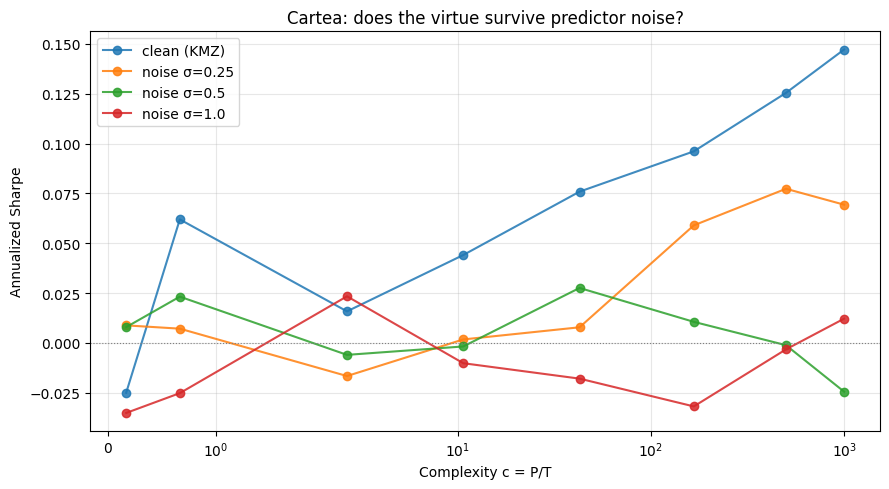

In [4]:
fig, ax = plt.subplots(figsize=(9,5))
for nz in noise_levels:
    sub = sweep_noisy[sweep_noisy["noise"]==nz].sort_values("complexity")
    lbl = "clean (KMZ)" if nz==0 else f"noise σ={nz}"
    ax.plot(sub["complexity"], sub["sharpe"], "o-", label=lbl, alpha=.85)
ax.set_xscale("symlog"); ax.axhline(0, color="grey", lw=.8, ls=":")
ax.set_xlabel("Complexity c = P/T"); ax.set_ylabel("Annualized Sharpe")
ax.set_title("Cartea: does the virtue survive predictor noise?")
ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); plt.show()
fig.savefig(f"{DEBATE}/cartea_noise.png", dpi=150, bbox_inches="tight")